# Multi-Layer Perceptron from Scratch

[Examples adopted from this notebook](https://colab.research.google.com/drive/1HzVYVikFmp2S_ks0nbkDcuwoTZBdyUbr?usp=sharing)

We'll build up a Multi-Layer Perceptron (MLP) in three steps:

1. **Manual computation** — implement a layer by hand using PyTorch tensors, on a tiny **pass / fail** prediction task.
2. **`nn.Linear`** — see how PyTorch packages the same math into a reusable layer.
3. **MNIST** — assemble the layers into a small network and run a forward pass on a hand-written digit.

A neural network layer transforms its inputs by multiplying them with a weight matrix, adding a bias, and applying an activation. Doing this as **one matrix multiplication** — instead of looping over neurons — is what makes deep learning fast.

![picture](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/2.2%20-%20Lab%20-%20Multi-Layer%20Perceptron%20and%20MNIST%20/vectorization.png)

## The pass / fail problem

We'll reuse the toy dataset from the [logistic-regression notebook](activation/01_logistic-regression-nn-pass-or-fail.ipynb): each student is described by **2 features** — the number of lectures attended and the hours spent on the final project — and the label is **1 = pass / 0 = fail**.

Our hand-built MLP will:

1. Pass the 2 features through a **hidden layer of 3 neurons** (matrix multiply, bias, ReLU).
2. Pass the 3 hidden activations through a **single output neuron** with a **sigmoid** to produce the probability of passing.

We'll do every step by hand with PyTorch tensors — exactly what `nn.Linear` does internally — so the operations stop being magic.

In [11]:
import torch

In [12]:
# Hidden layer weights: 2 input features (lectures, hours) -> 3 neurons.
# Each ROW is one neuron, each COLUMN is one input feature.
#   neuron 1 -> "general engagement"  (small weight on each feature)
#   neuron 2 -> "lecture-focused"     (only looks at lectures)
#   neuron 3 -> "project-focused"     (only looks at hours)
WeightMatrix = torch.tensor([
    [0.10, 0.20],
    [0.30, 0.00],
    [0.00, 0.40]
])

# One student, with two features: 15 lectures attended, 10 hours on the project.
# Shape (2, 1): a column vector with one feature per row.
Input_1 = torch.tensor([
    [15.],
    [10.]
])

WeightMatrix, Input_1

(tensor([[0.1000, 0.2000],
         [0.3000, 0.0000],
         [0.0000, 0.4000]]),
 tensor([[15.],
         [10.]]))

In [13]:
# One matrix multiplication = weighted sum for every neuron at once.
# Each row of the result is one neuron's pre-activation for this student:
#   neuron 1: 0.10*15 + 0.20*10 = 3.5
#   neuron 2: 0.30*15 + 0.00*10 = 4.5
#   neuron 3: 0.00*15 + 0.40*10 = 4.0
torch.matmul(WeightMatrix, Input_1)

tensor([[3.5000],
        [4.5000],
        [4.0000]])

In [14]:
# Same matmul, but now with a batch of 3 students stacked as COLUMNS.
# Row 0 = lectures attended, row 1 = project hours.
#   student 1 -> (15, 10)   (high engagement)
#   student 2 -> (10,  6)   (medium)
#   student 3 -> ( 5,  2)   (low)
Input_1 = torch.tensor([
    [15., 10., 5.],
    [10.,  6., 2.]
])

# Output shape (3, 3): one row per neuron, one column per student.
torch.matmul(WeightMatrix, Input_1)

tensor([[3.5000, 2.2000, 0.9000],
        [4.5000, 3.0000, 1.5000],
        [4.0000, 2.4000, 0.8000]])

## Reshaping the input

Stacking samples as **columns** matches the math we just did, but in practice it's more natural to have **one row per sample** — that's how DataFrames, CSVs, and `nn.Linear` all expect data. To keep the multiplication valid we then need to **transpose** the weight matrix so its inner dimension lines up with the features.

In [15]:
# Same 3 students, but now arranged as ROWS: shape (3, 2).
#   row 0 -> student 1 (15 lectures, 10 hours)
#   row 1 -> student 2 (10 lectures,  6 hours)
#   row 2 -> student 3 ( 5 lectures,  2 hours)
Input_2 = torch.tensor([
    [15., 10.],
    [10.,  6.],
    [ 5.,  2.]
])

Input_2.shape

torch.Size([3, 2])

In [16]:
# This would fail: matmul requires the inner dimensions to match.
# WeightMatrix is (3, 2) and Input_2 is (3, 2) — not compatible.
# torch.matmul(WeightMatrix, Input_2)

In [17]:
# Transposing flips rows and columns: shape (3, 2) -> (2, 3).
# After transposing, each COLUMN of W.T holds one neuron's weights.
WeightMatrix.T

tensor([[0.1000, 0.3000, 0.0000],
        [0.2000, 0.0000, 0.4000]])

In [18]:
# (3 students, 2 features) @ (2 features, 3 neurons) -> (3 students, 3 neurons).
# Each row of the result is one student's pre-activations for the 3 hidden neurons.
torch.matmul(Input_2, WeightMatrix.T)

tensor([[3.5000, 4.5000, 4.0000],
        [2.2000, 3.0000, 2.4000],
        [0.9000, 1.5000, 0.8000]])

## Adding a bias

Each neuron also has its own **bias** — a learnable shift added after the weighted sum, so the neuron can fire (or stay silent) independent of the input scale. With one bias per neuron, the bias vector has length equal to the number of outputs (here, 3).

We pick **negative** biases on purpose: a student needs *enough* lectures and project hours before any neuron activates, mirroring a real "passing threshold".

In [19]:
# One bias per hidden neuron. Negative values mean each neuron has to be "earned".
bias = torch.tensor([-2.0, -3.0, -2.0])

In [20]:
# matmul + bias, broadcast across all 3 students.
# Notice student 3 (5 lectures, 2 hours) ends up with NEGATIVE pre-activations everywhere
# — the bias has filtered out a low-engagement student before the activation even runs.
torch.matmul(Input_2, WeightMatrix.T) + bias

tensor([[ 1.5000,  1.5000,  2.0000],
        [ 0.2000,  0.0000,  0.4000],
        [-1.1000, -1.5000, -1.2000]])

## Adding an activation function

An activation introduces **non-linearity** — without it, stacking layers would just collapse into one big linear function. We'll use **ReLU** (Rectified Linear Unit):

$$\text{ReLU}(x) = \max(0, x)$$

It simply replaces negative values with zero. In our setup this means a low-engagement student ends up with all hidden neurons silenced — exactly what we want before deciding pass / fail.

In [21]:
x = torch.matmul(Input_2, WeightMatrix.T) + bias

# ReLU: clamp every value to be at least 0.
#   student 1 (15, 10) -> stays positive on every neuron
#   student 2 (10,  6) -> one neuron clipped to 0
#   student 3 ( 5,  2) -> ALL neurons zeroed -> "no signal" before the output layer
torch.clamp(x, min=0)

tensor([[1.5000, 1.5000, 2.0000],
        [0.2000, 0.0000, 0.4000],
        [0.0000, 0.0000, 0.0000]])

## Adding an output layer + sigmoid

So far we've computed the hidden representation `h` (shape `(3 students, 3 neurons)`). To get a final **probability of passing** we need one more layer that maps those 3 hidden activations down to a single number, and then squash it into `(0, 1)`.

- **Output layer**: a tiny `Linear(3, 1)` — one weight per hidden neuron + one bias — produces a raw score (a "logit").
- **Sigmoid**: $\sigma(z) = \dfrac{1}{1 + e^{-z}}$ turns the logit into a probability.

This is exactly the structure used by the [logistic-regression notebook](activation/01_logistic-regression-nn-pass-or-fail.ipynb) — except the inputs to the sigmoid are now *learned features* coming from a hidden layer instead of the raw inputs.

In [22]:
# Output layer: 3 hidden neurons -> 1 output (the pass/fail score).
# W_out shape (1, 3): one row, one weight per hidden neuron.
W_out = torch.tensor([[1.0, 1.0, 1.0]])
b_out = torch.tensor([-3.0])

# Hidden activations h are exactly what came out of ReLU above.
h = torch.clamp(torch.matmul(Input_2, WeightMatrix.T) + bias, min=0)
h

tensor([[1.5000, 1.5000, 2.0000],
        [0.2000, 0.0000, 0.4000],
        [0.0000, 0.0000, 0.0000]])

In [23]:
# Linear part of the output layer:  z = h @ W_out.T + b_out
z = torch.matmul(h, W_out.T) + b_out

# Sigmoid squashes the logit z into a probability in (0, 1).
probabilities = torch.sigmoid(z)

# Each row is now one student's predicted probability of passing.
z, probabilities

(tensor([[ 2.0000],
         [-2.4000],
         [-3.0000]]),
 tensor([[0.8808],
         [0.0832],
         [0.0474]]))

**Reading the result.** Even with these hand-picked (untrained) weights, our 2-layer network already produces sensible scores:

| student | (lectures, hours) | logit `z` | sigmoid(`z`) | predicted |
|---------|-------------------|-----------|--------------|-----------|
| 1 | (15, 10) |  2.0 | ~0.88 | **pass** |
| 2 | (10,  6) | -2.4 | ~0.08 | **fail** |
| 3 | ( 5,  2) | -3.0 | ~0.05 | **fail** |

Everything we just did — `matmul`, `+ bias`, `ReLU`, another `matmul`, `+ bias`, `sigmoid` — is exactly what PyTorch's higher-level building blocks (`nn.Linear`, `F.relu`, `torch.sigmoid`) do for us next. In a real workflow, gradient descent would *learn* values for `WeightMatrix`, `bias`, `W_out`, and `b_out` from labelled data instead of us picking them by hand.

# Using `nn.Linear`

We've now seen the math of a layer up close. Doing it by hand every time gets tedious — and we still need to track parameters, gradients, and devices. PyTorch's **`nn.Linear`** wraps the weight matrix, bias, and matmul into a single reusable building block.

![picture](https://upload.wikimedia.org/wikipedia/commons/9/96/Pytorch_logo.png?20211003060202)

In [24]:
import torch
from torch import nn

### The Linear layer

`nn.Linear(in_features, out_features)` creates a layer with a randomly-initialised weight matrix and a bias vector. Calling the layer performs exactly the operation we just did by hand:

$$y = x\,W^\top + b$$

To verify, we'll override its random weights with the same values we used above and confirm we get the same numbers.

In [25]:
layer = nn.Linear(2,3)

In [26]:
layer.bias

Parameter containing:
tensor([-0.3140, -0.5869, -0.2426], requires_grad=True)

In [27]:
# Override the random weights with the exact values used in the manual section above.
layer.weight.data = torch.tensor([
    [0.10, 0.20],
    [0.30, 0.00],
    [0.00, 0.40]
])

layer.weight


Parameter containing:
tensor([[0.1000, 0.2000],
        [0.3000, 0.0000],
        [0.0000, 0.4000]], requires_grad=True)

In [28]:
layer.bias.data = torch.tensor([-2.0, -3.0, -2.0])


In [29]:
# The same 3 students as the manual section (lectures, hours).
Input = torch.tensor([
    [15., 10.],
    [10.,  6.],
    [ 5.,  2.]
])

Input

tensor([[15., 10.],
        [10.,  6.],
        [ 5.,  2.]])

In [30]:
layer(Input)

tensor([[ 1.5000,  1.5000,  2.0000],
        [ 0.2000,  0.0000,  0.4000],
        [-1.1000, -1.5000, -1.2000]], grad_fn=<AddmmBackward0>)

In [31]:
import torch.nn.functional as F

x= layer(Input)
F.relu(x)

tensor([[1.5000, 1.5000, 2.0000],
        [0.2000, 0.0000, 0.4000],
        [0.0000, 0.0000, 0.0000]], grad_fn=<ReluBackward0>)

# Recognising digits

Time to build a real classifier. We'll use **MNIST** — a dataset of 28×28 grayscale images of hand-written digits (0–9), the canonical "Hello World" of deep learning.

The plan:

1. Load and inspect a single image.
2. Convert it to a tensor.
3. Define an MLP and run a forward pass to predict the digit.

In [32]:
# Download and extract the dataset

!wget https://github.com/kyuz0/mnist-png/raw/main/mnist.tgz
!tar xzf mnist.tgz

--2026-05-04 15:18:36--  https://github.com/kyuz0/mnist-png/raw/main/mnist.tgz
Resolving github.com (github.com)... 20.207.73.82
Connecting to github.com (github.com)|20.207.73.82|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/kyuz0/mnist-png/main/mnist.tgz [following]
--2026-05-04 15:18:37--  https://raw.githubusercontent.com/kyuz0/mnist-png/main/mnist.tgz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18294568 (17M) [application/octet-stream]
Saving to: ‘mnist.tgz.1’

mnist.tgz.1         100%[===================>]  17.45M  8.40MB/s    in 2.1s    

2026-05-04 15:18:40 (8.40 MB/s) - ‘mnist.tgz.1’ saved [18294568/18294568]



In [33]:
from PIL import Image
import torchvision.transforms as transforms


In [34]:
image_path = 'mnist/training/0/1.png'
image = Image.open(image_path)
image

## From image to tensor

A neural network can't read a PNG directly — we need to convert the image into a tensor of pixel intensities. `transforms.ToTensor()` does this and also rescales each pixel from `0..255` (8-bit greyscale) to a float in `0.0..1.0`.

![picture](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/2.2%20-%20Lab%20-%20Multi-Layer%20Perceptron%20and%20MNIST%20/input.png)

In [35]:
# Define the transformation
transform = transforms.Compose([
    transforms.ToTensor()
])

# Apply the transformation to the image
tensor_image = transform(image).squeeze(0)

# Check the shape of the tensor
print(tensor_image.shape)

tensor_image[20][22]

torch.Size([28, 28])


tensor(1.)

In [36]:
tensor_image

tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000

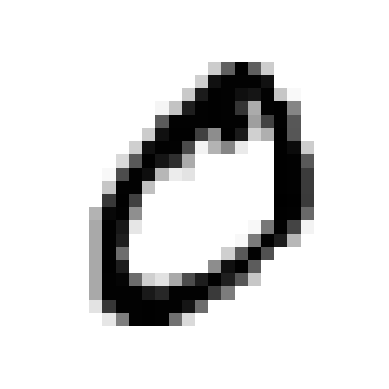

In [37]:
import matplotlib.pyplot as plt

def imshow(tensor_image):
    plt.imshow(tensor_image, cmap='gray')
    plt.axis('off')
    plt.show()

# Display the tensor image using matplotlib
imshow(tensor_image)

## Defining the model

Our MLP has three fully-connected layers:

| Layer | Inputs | Outputs | Activation |
|-------|--------|---------|------------|
| 1 | 28 × 28 = 784 | 100 | ReLU |
| 2 | 100 | 150 | ReLU |
| 3 (output) | 150 | 10 | none — raw **logits** |

The final layer outputs one number per digit class. We **don't** apply an activation here: the loss function (during training) and `softmax` (for inference) will handle that.

![picture](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/2.2%20-%20Lab%20-%20Multi-Layer%20Perceptron%20and%20MNIST%20/mpl.png)

In [38]:
import torch.nn.functional as F

class MNISTNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.Layer1 = nn.Linear(28*28, 100)
    self.Layer2 = nn.Linear(100, 150)
    self.Layer3 = nn.Linear(150, 10)

  def forward(self, x):
    x =  F.relu(self.Layer1(x))
    x =  F.relu(self.Layer2(x))
    x =  self.Layer3(x)
    return x

In [39]:
model = MNISTNet()
model

MNISTNet(
  (Layer1): Linear(in_features=784, out_features=100, bias=True)
  (Layer2): Linear(in_features=100, out_features=150, bias=True)
  (Layer3): Linear(in_features=150, out_features=10, bias=True)
)

In [40]:
for name, param in model.named_parameters():
    print(f"Name: {name}")
    print(f"Value: {param.data}")
    print("------")

Name: Layer1.weight
Value: tensor([[-0.0199,  0.0314, -0.0318,  ...,  0.0093,  0.0317,  0.0173],
        [-0.0089, -0.0042,  0.0221,  ...,  0.0217,  0.0157, -0.0255],
        [ 0.0032, -0.0163, -0.0191,  ...,  0.0287, -0.0287,  0.0215],
        ...,
        [ 0.0059,  0.0042, -0.0279,  ...,  0.0326,  0.0289, -0.0174],
        [ 0.0151, -0.0011,  0.0179,  ...,  0.0292, -0.0184, -0.0218],
        [ 0.0296, -0.0086, -0.0298,  ...,  0.0145,  0.0073,  0.0272]])
------
Name: Layer1.bias
Value: tensor([-0.0257,  0.0314, -0.0278,  0.0330, -0.0248,  0.0016, -0.0312, -0.0141,
        -0.0070,  0.0061, -0.0044, -0.0215, -0.0279,  0.0006,  0.0029, -0.0101,
         0.0325, -0.0125, -0.0251, -0.0304,  0.0118, -0.0302,  0.0273, -0.0235,
         0.0317, -0.0270,  0.0104,  0.0206,  0.0195, -0.0227, -0.0068,  0.0328,
        -0.0222, -0.0065,  0.0289, -0.0273, -0.0166, -0.0321,  0.0207, -0.0261,
         0.0069,  0.0047,  0.0085, -0.0143, -0.0355, -0.0084, -0.0226, -0.0038,
        -0.0226,  0.0294,  

In [41]:
model.Layer3.weight.shape

torch.Size([10, 150])

## Forward pass

To run a single image through the network we need to:

1. **Flatten** the 28×28 image into a 784-vector.
2. **Add a batch dimension** → shape `(1, 784)` (the model always expects a batch).
3. Pass it through the model to get **10 logits** — one per digit.
4. Apply **softmax** to turn the logits into probabilities that sum to 1.

The model is untrained, so the probabilities will all be roughly `0.1`.

![picture](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/2.2%20-%20Lab%20-%20Multi-Layer%20Perceptron%20and%20MNIST%20/multi-class.png)

In [42]:
tensor_image.reshape(1,28*28)

tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0

In [43]:
y_hat = model(tensor_image.reshape(1,28*28))

In [44]:
y_hat

tensor([[ 0.0200, -0.0698, -0.1310, -0.0903,  0.0256, -0.0779, -0.1688, -0.0292,
          0.1134,  0.0497]], grad_fn=<AddmmBackward0>)

In [45]:
F.softmax(y_hat, dim=1)

tensor([[0.1054, 0.0963, 0.0906, 0.0944, 0.1060, 0.0955, 0.0872, 0.1003, 0.1157,
         0.1086]], grad_fn=<SoftmaxBackward0>)

# Running on a GPU

GPUs are dramatically faster than CPUs at the matrix operations we just saw. In PyTorch, moving a model and its inputs to the GPU is a one-line change with `.to(DEVICE)`.

**Important:** the model and its inputs must live on the **same device**, otherwise PyTorch will raise an error.

![picture](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/2.2%20-%20Lab%20-%20Multi-Layer%20Perceptron%20and%20MNIST%20/gpus.png)

In [46]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DEVICE

/home/erradi/.venvs/ml-env/lib/python3.14/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


device(type='cpu')

In [47]:
model.to(DEVICE)

y_hat = model(tensor_image.reshape(1,28*28).to(DEVICE))

In [48]:
y_hat

tensor([[ 0.0200, -0.0698, -0.1310, -0.0903,  0.0256, -0.0779, -0.1688, -0.0292,
          0.1134,  0.0497]], grad_fn=<AddmmBackward0>)